# Parte 2: Auditoria do Modelo em Produção

## Desempenho com Incerteza e Análise de Falhas

**Objetivo**: Avaliar o desempenho global do modelo A com rigor estatístico, e investigar onde e por que o modelo falha, identificando padrões nos erros que impactam o encaminhamento dos chamados.

## Setup

In [21]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.metrics import balanced_accuracy_score


DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures/')

## 2. Desempenho com Incerteza

In [2]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')

y_true = df['categoria_real']
y_pred = df['pred_modelo_a']
classes = sorted(df['categoria_real'].unique())

cat_map = {
    'iluminacao_publica': 'Iluminação Pública',
    'buraco_via': 'Buraco em Via',
    'coleta_lixo': 'Coleta de Lixo',
    'esgoto_vazamento': 'Vazamento de Esgoto',
    'poda_arvore': 'Poda de Árvore',
    'estacionamento_irregular': 'Estacionamento Irregular',
    'barulho_perturbacao': 'Barulho / Perturbação',
    'sinalizacao': 'Sinalização'
}

In [3]:
RANDOM_STATE = 42
N_BOOTSTRAP = 1000

def bootstrap_ic(y_true, y_pred, metric_fn, n_bootstrap=N_BOOTSTRAP, ic=95, random_state=RANDOM_STATE):
    """
    Calcula valor observado e IC via bootstrap para uma métrica.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    indices = np.arange(n)
    
    observed = metric_fn(y_true, y_pred)
    boot_values = []
    
    for _ in range(n_bootstrap):
        idx = rng.choice(indices, size=n, replace=True)
        boot_values.append(metric_fn(y_true.iloc[idx], y_pred.iloc[idx]))
    
    lower = np.percentile(boot_values, (100 - ic) / 2)
    upper = np.percentile(boot_values, 100 - (100 - ic) / 2)
    
    return observed, boot_values, lower, upper

In [4]:
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def weighted_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics_global = [
    ('Acurácia', accuracy_score),
    ('Balanced Accuracy', balanced_accuracy_score),
    ('F1 Macro', macro_f1),
    ('F1 Weighted', weighted_f1)
]

results_global = []
bootstrap_distributions = {}

for name, fn in metrics_global:
    observed, boots_values, low, high = bootstrap_ic(y_true, y_pred, fn)
    results_global.append({
        'Métrica': name,
        'Valor observado': observed,
        'IC 95% - inferior': low,
        'IC 95% - superior': high,
        'IC 95%': f'[{low:.3f}, {high:.3f}]'
    })
    bootstrap_distributions[name] = np.asarray(boots_values)

metrics_global_df = pd.DataFrame(results_global)
metrics_global_df[['Métrica', 'Valor observado', 'IC 95%']] \
    .style.format({'Valor observado': '{:.3f}'})

,Métrica,Valor observado,IC 95%
0,Acurácia,0.773,"[0.761, 0.784]"
1,Balanced Accuracy,0.771,"[0.757, 0.784]"
2,F1 Macro,0.770,"[0.757, 0.782]"
3,F1 Weighted,0.773,"[0.760, 0.784]"


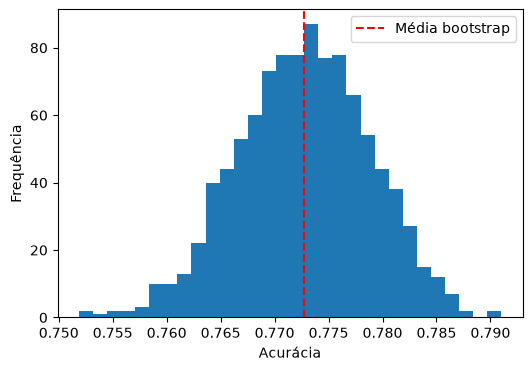

In [11]:
values = bootstrap_distributions["F1 Weighted"]

plt.figure(figsize=(6,4))
plt.hist(values, bins=30)
plt.axvline(values.mean(), color="red", linestyle="--", label="Média bootstrap")
plt.legend()
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.show()

In [6]:
results = []

classes = sorted(pd.Series(y_true).unique())
for cls in classes:
    y_true_bin = (pd.Series(y_true) == cls).astype(int)
    y_pred_bin = (pd.Series(y_pred) == cls).astype(int)

    precision, _, p_low, p_high = bootstrap_ic(
        y_true_bin,
        y_pred_bin,
        lambda yt, yp: precision_score(
            yt, yp, zero_division=0
        )
    )

    recall, _, r_low, r_high = bootstrap_ic(
        y_true_bin,
        y_pred_bin,
        lambda yt, yp: recall_score(
            yt, yp, zero_division=0
        )
    )

    f1, _, f_low, f_high = bootstrap_ic(
        y_true_bin,
        y_pred_bin,
        lambda yt, yp: f1_score(
            yt, yp, zero_division=0
        )
    )

    support = (y_true_bin == 1).sum()
    erros = ((y_true_bin == 1) & (y_pred_bin == 0)).sum()

    results.append({
        "Categoria": cat_map.get(cls, cls),
        "Suporte": support,
        "Erros": erros,
        "Taxa de erro": erros / support,
        "Precision": precision,
        "Precision IC 95%": f"[{p_low:.3f}, {p_high:.3f}]",
        "Recall": recall,
        "Recall IC 95%": f"[{r_low:.3f}, {r_high:.3f}]",
        "F1": f1,
        "F1 IC 95%": f"[{f_low:.3f}, {f_high:.3f}]"
    })

metrics_by_class_df = pd.DataFrame(results).sort_values("F1")

In [7]:
metrics_by_class_df 

,Categoria,Suporte,Erros,Taxa de erro,Precision,Precision IC 95%,Recall,Recall IC 95%,F1,F1 IC 95%
3,Vazamento de Esgoto,621,262,0.421900,0.712302,"[0.672, 0.752]",0.578100,"[0.539, 0.618]",0.638222,"[0.605, 0.672]"
1,Buraco em Via,908,166,0.182819,0.664279,"[0.636, 0.693]",0.817181,"[0.792, 0.841]",0.732840,"[0.710, 0.755]"
7,Sinalização,227,46,0.202643,0.741803,"[0.688, 0.798]",0.797357,"[0.747, 0.847]",0.768577,"[0.726, 0.807]"
0,Barulho / Perturbação,400,90,0.225000,0.801034,"[0.763, 0.837]",0.775000,"[0.733, 0.816]",0.787802,"[0.756, 0.819]"
6,Poda de Árvore,458,103,0.224891,0.803167,"[0.768, 0.841]",0.775109,"[0.738, 0.815]",0.788889,"[0.760, 0.820]"
2,Coleta de Lixo,806,156,0.193548,0.814536,"[0.787, 0.843]",0.806452,"[0.779, 0.832]",0.810474,"[0.789, 0.831]"
4,Estacionamento Irregular,437,76,0.173913,0.800443,"[0.761, 0.839]",0.826087,"[0.792, 0.859]",0.813063,"[0.784, 0.839]"
5,Iluminação Pública,1143,237,0.207349,0.857143,"[0.835, 0.877]",0.792651,"[0.768, 0.816]",0.823636,"[0.806, 0.841]"


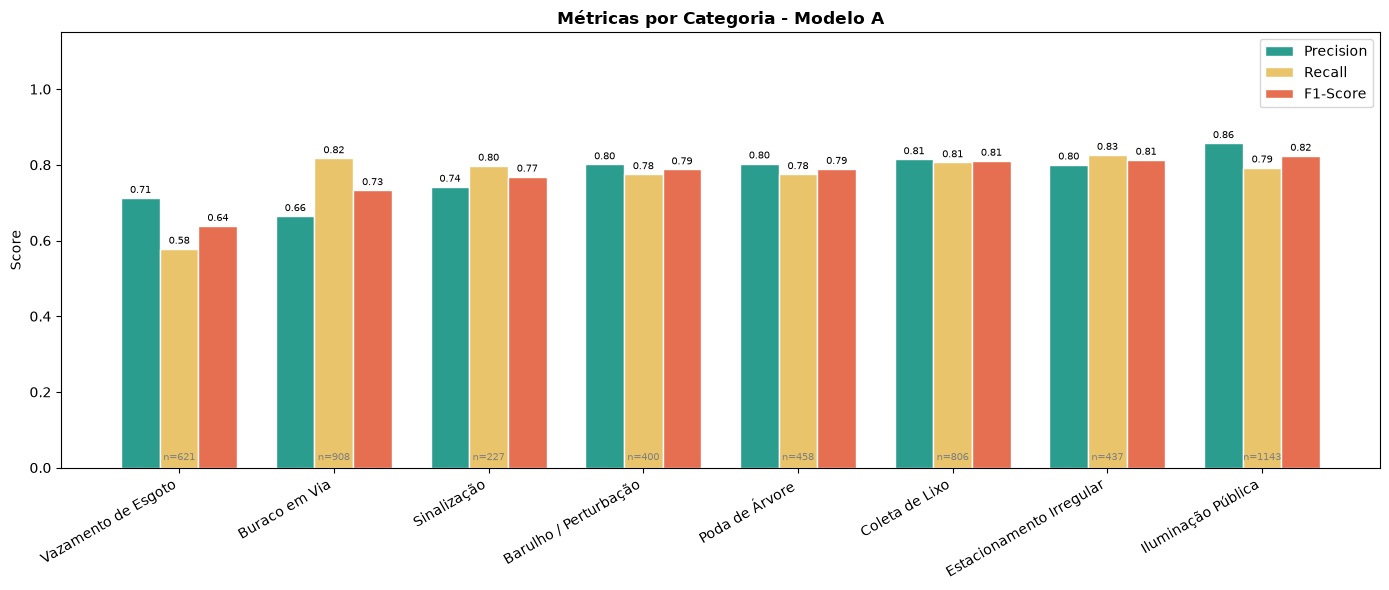

In [24]:
metrics_plot_df = metrics_by_class_df.sort_values('F1').copy()

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_plot_df))
width = 0.25

bars1 = ax.bar(
    x - width,
    metrics_plot_df['Precision'],
    width,
    label='Precision',
    color='#2a9d8f',
    edgecolor='white'
)

bars2 = ax.bar(
    x,
    metrics_plot_df['Recall'],
    width,
    label='Recall',
    color='#e9c46a',
    edgecolor='white'
)

bars3 = ax.bar(
    x + width,
    metrics_plot_df['F1'],
    width,
    label='F1-Score',
    color='#e76f51',
    edgecolor='white'
)

for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot_df['Categoria'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Métricas por Categoria - Modelo A', fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.15)

for i, row in metrics_plot_df.reset_index(drop=True).iterrows():
    ax.annotate(
        f'n={row["Suporte"]}',
        (x[i], 0.02),
        ha='center',
        fontsize=7,
        color='gray'
    )

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'metricas_por_classe_A.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Onde o Modelo Falha? 

### 3.1 Matriz de Confusão

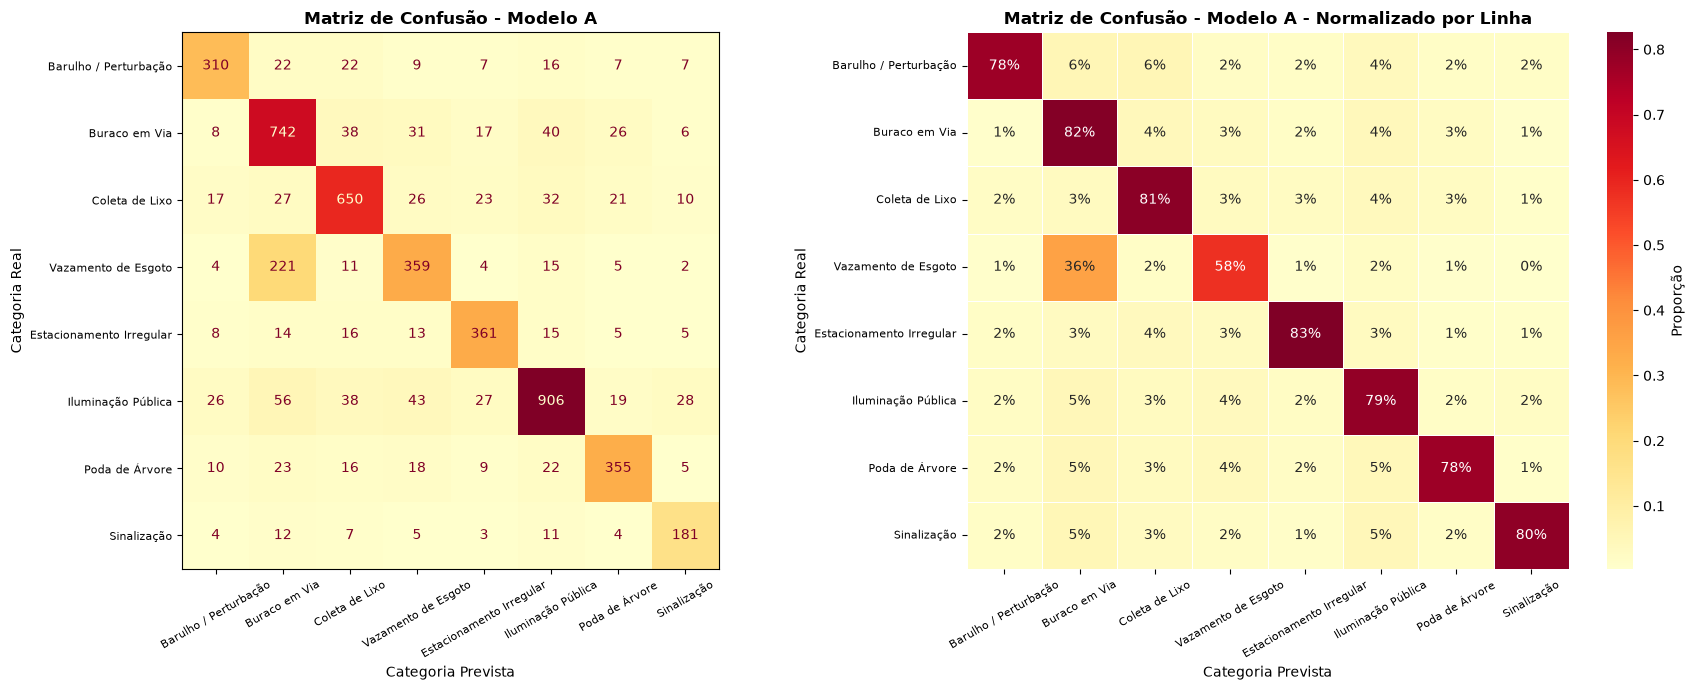

In [25]:
cm = confusion_matrix(y_true, y_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz absoluta
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[cat_map.get(c, c) for c in classes])
disp.plot(ax=axes[0], cmap='YlOrRd', values_format='d', colorbar=False)
axes[0].set_title('Matriz de Confusão - Modelo A', fontweight='bold')
axes[0].set_ylabel('Categoria Real')
axes[0].set_xlabel('Categoria Prevista')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Matriz normalizada (por linha = recall)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='YlOrRd',
            xticklabels=[cat_map.get(c, c) for c in classes],
            yticklabels=[cat_map.get(c, c) for c in classes],
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Proporção'})
axes[1].set_title('Matriz de Confusão - Modelo A - Normalizado por Linha', fontweight='bold')
axes[1].set_ylabel('Categoria Real')
axes[1].set_xlabel('Categoria Prevista')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'matriz_confusao_A.png', bbox_inches='tight', dpi=150)
plt.show()

In [17]:
top_errors = []
for real in classes:
    for pred in classes:
        if real != pred:
            count = cm[classes.index(real), classes.index(pred)]
            if count > 0:
                top_errors.append({
                    'Real': cat_map.get(real, real),
                    'Previsto': cat_map.get(pred, pred),
                    'Chamados': count
                })

top_errors_df = pd.DataFrame(top_errors).sort_values('Chamados', ascending=False).head(15)
print('Top 15 pares de erro (Real → Previsto):')
top_errors_df

Top 15 pares de erro (Real → Previsto):


,Real,Previsto,Chamados
22,Vazamento de Esgoto,Buraco em Via,221
36,Iluminação Pública,Buraco em Via,56
38,Iluminação Pública,Vazamento de Esgoto,43
11,Buraco em Via,Iluminação Pública,40
37,Iluminação Pública,Coleta de Lixo,38
8,Buraco em Via,Coleta de Lixo,38
18,Coleta de Lixo,Iluminação Pública,32
9,Buraco em Via,Vazamento de Esgoto,31
41,Iluminação Pública,Sinalização,28
39,Iluminação Pública,Estacionamento Irregular,27


### 3.2 Falhas por Subgrupos

In [19]:
df['erro'] = df['categoria_real'] != df['pred_modelo_a']

print('Taxa de erro por categoria:')
error_by_cat = df.groupby('categoria_real')['erro'].agg(['mean', 'count', 'sum'])
error_by_cat.columns = ['Taxa Erro', 'Total', 'Erros']
error_by_cat.index = [cat_map.get(c, c) for c in error_by_cat.index]
error_by_cat = error_by_cat.sort_values('Taxa Erro', ascending=False)
print(error_by_cat.to_string())
print()

print(f'Total de erros: {df["erro"].sum()} / {len(df)} ({df["erro"].mean()*100:.1f}%)')

Taxa de erro por categoria:
                          Taxa Erro  Total  Erros
Vazamento de Esgoto        0.421900    621    262
Barulho / Perturbação      0.225000    400     90
Poda de Árvore             0.224891    458    103
Iluminação Pública         0.207349   1143    237
Sinalização                0.202643    227     46
Coleta de Lixo             0.193548    806    156
Buraco em Via              0.182819    908    166
Estacionamento Irregular   0.173913    437     76

Total de erros: 1136 / 5000 (22.7%)


In [31]:
print('Taxa de erro por canal:')

error_by_canal = df.groupby('canal')['erro'].agg(['mean', 'count', 'sum'])
error_by_canal.columns = ['Taxa Erro', 'Total', 'Erros']

error_by_canal_fmt = error_by_canal.copy()
error_by_canal_fmt['Taxa Erro (%)'] = error_by_canal_fmt['Taxa Erro'] * 100
error_by_canal_fmt = error_by_canal_fmt[['Taxa Erro (%)', 'Total', 'Erros']]

display(error_by_canal_fmt.round({'Taxa Erro (%)': 1}))

print('Taxa de erro por bairro - top 10 por número de erros:')

error_by_bairro = df.groupby('bairro')['erro'].agg(['mean', 'count', 'sum'])
error_by_bairro.columns = ['Taxa Erro', 'Total', 'Erros']

top_error_bairros = error_by_bairro.sort_values('Erros', ascending=False).head(10).copy()
top_error_bairros['Taxa Erro (%)'] = top_error_bairros['Taxa Erro'] * 100
top_error_bairros = top_error_bairros[['Taxa Erro (%)', 'Total', 'Erros']]

display(top_error_bairros.round({'Taxa Erro (%)': 1}))

tau, p_value = stats.kendalltau(error_by_bairro['Total'], error_by_bairro['Taxa Erro'])
print(f'Kendall tau = {tau:.3f}; p = {p_value:.4f}')

Taxa de erro por canal:


,Taxa Erro (%),Total,Erros
canal,,,
app_1746,23.6,2408,568
portal_web,22.0,868,191
telefone_1746,21.9,1724,377


Taxa de erro por bairro - top 10 por número de erros:


,Taxa Erro (%),Total,Erros
bairro,,,
Campo Grande,21.8,533,116
Jacarepaguá,21.4,467,100
Bangu,21.1,435,92
Barra da Tijuca,22.8,403,92
Tijuca,23.3,387,90
Santa Cruz,24.3,358,87
Madureira,25.0,340,85
Copacabana,21.1,350,74
Centro,23.9,305,73


Kendall tau = -0.105; p = 0.6265


In [32]:
print('Taxa de erro por faixa de confiança do modelo A:')

bins = [0, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
labels = ['<70%', '70-80%', '80-85%', '85-90%', '90-95%', '>95%']

df['conf_faixa'] = pd.cut(
    df['conf_modelo_a'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

error_by_conf = df.groupby('conf_faixa', observed=True)['erro'].agg(['mean', 'count', 'sum'])
error_by_conf.columns = ['Taxa Erro', 'Total', 'Erros']

error_by_conf_fmt = error_by_conf.copy()
error_by_conf_fmt['Taxa Erro (%)'] = error_by_conf_fmt['Taxa Erro'] * 100
error_by_conf_fmt = error_by_conf_fmt[['Taxa Erro (%)', 'Total', 'Erros']]

display(error_by_conf_fmt.round({'Taxa Erro (%)': 1}))

high_conf_erros = df[(df['conf_modelo_a'] >= 0.95) & (df['erro'])]
print(
    f'Erros com confiança >= 95%: {len(high_conf_erros)} '
    f'({len(high_conf_erros) / df["erro"].sum() * 100:.1f}% dos erros totais)'
)

if len(high_conf_erros) > 0:
    print('Distribuição dos erros de alta confiança por categoria real:')
    hc_err_cat = high_conf_erros['categoria_real'].value_counts()
    hc_err_cat.index = [cat_map.get(c, c) for c in hc_err_cat.index]
    print(hc_err_cat.to_string())

Taxa de erro por faixa de confiança do modelo A:


,Taxa Erro (%),Total,Erros
conf_faixa,,,
<70%,12.5,8,1
70-80%,20.9,134,28
80-85%,26.4,318,84
85-90%,21.3,928,198
90-95%,22.9,1864,426
>95%,22.8,1748,399



Erros com confiança >= 95%: 415 (36.5% dos erros totais)

Distribuição dos erros de alta confiança por categoria real:
Vazamento de Esgoto         92
Iluminação Pública          89
Coleta de Lixo              62
Buraco em Via               59
Poda de Árvore              43
Barulho / Perturbação       25
Sinalização                 24
Estacionamento Irregular    21
